# Exploratory Data Analysis

This notebook examines the lap-level data recorded for the project and documents the decisions used to create the final modelling dataset.

The analysis focuses on three questions:

1. How do the recorded Sector 1 times vary across the data-collection period?
2. Is there any visible relationship between Sector 1 time and the recorded brake–throttle deltas?
3. How should eligible laps be divided into the three performance classes used by the models?

## Scope and limitations

The data-collection process was designed to keep the game conditions consistent, but braking and throttle position are not the only factors that affect Sector 1 time. Steering input, racing line, corner-entry speed and other unrecorded driver actions may also influence performance.

Incident labels are also based partly on the game's crash and track-limits detection. These labels are useful for excluding clearly invalid laps, but they should not be treated as a complete description of every driving error.

## Initial expectations

- Longer brake–throttle deltas may be associated with slower Sector 1 times because the car may spend longer away from full acceleration.
- Sector performance may improve over the course of data collection as familiarity with the track increases.
- Laps with crashes, track-limits violations, unusually long sector times or incomplete screenshot sequences should be excluded before assigning performance labels.

## Loading the collated lap data


In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("../../Data/collated-data/lap-image-association.csv")

df = pd.read_csv(DATA_PATH)

print(f"Total recorded laps: {len(df)}")
df.head()


Total recorded laps: 255


,lap_num,s1_time,incident,related_b_hits,related_t_hits,brake_throttle_deltas
0,1,28719,track limit violation,['../Data/image-data/session-1/brake/Lap_1_tra...,['../Data/image-data/session-1/throttle/Lap_1_...,[]
1,2,51823,crash,['../Data/image-data/session-1/brake/Lap_2_cra...,['../Data/image-data/session-1/throttle/Lap_2_...,[]
2,3,28935,none,['../Data/image-data/session-1/brake/Lap_3_Bra...,['../Data/image-data/session-1/throttle/Lap_3_...,[]
3,4,29188,none,['../Data/image-data/session-1/brake/Lap_4_Bra...,['../Data/image-data/session-1/throttle/Lap_4_...,[]
4,5,28478,none,['../Data/image-data/session-1/brake/Lap_5_Bra...,['../Data/image-data/session-1/throttle/Lap_5_...,[]


## 1. Recorded Sector 1 Times

The first plot shows the Sector 1 time for every recorded lap, including laps associated with incidents or unusually long sector times.


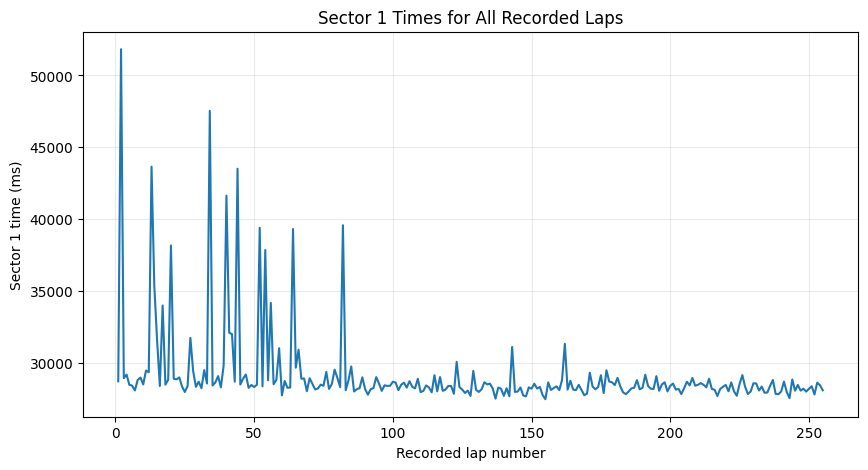

Total laps recorded: 255


In [2]:
plt.figure(figsize=(10, 5))
plt.plot(df["lap_num"], df["s1_time"])
plt.title("Sector 1 Times for All Recorded Laps")
plt.xlabel("Recorded lap number")
plt.ylabel("Sector 1 time (ms)")
plt.grid(alpha=0.25)
plt.show()

print(f"Total laps recorded: {len(df)}")


Several laps have substantially longer Sector 1 times than the main body of the data. Some of these laps are associated with crashes or track-limits violations, while others may contain delays that make them unsuitable for comparison with ordinary laps.

The vehicle was configured to be indestructible and tyre degradation was disabled during collection. This prevented accumulated damage or tyre wear from changing the car between sessions, but incident laps could still contain large time losses while the car returned to the track.


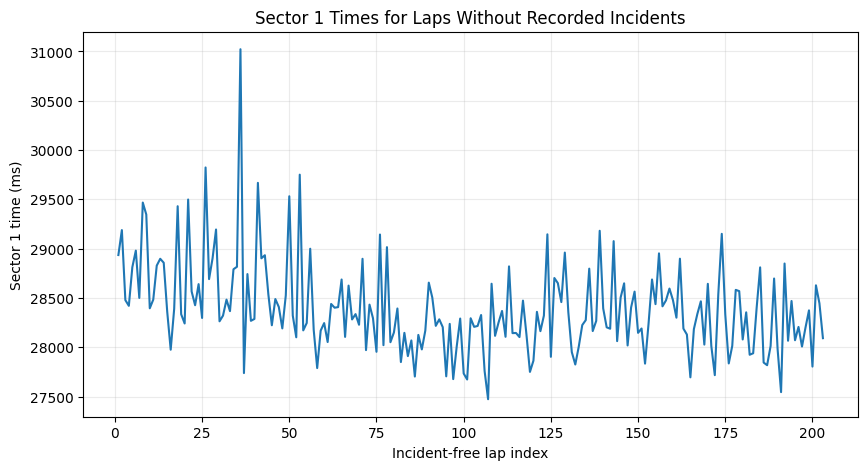

Laps without a recorded incident: 203


In [3]:
incident_free_df = df.loc[df["incident"].eq("none")].copy()

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1, len(incident_free_df) + 1),
    incident_free_df["s1_time"]
)
plt.title("Sector 1 Times for Laps Without Recorded Incidents")
plt.xlabel("Incident-free lap index")
plt.ylabel("Sector 1 time (ms)")
plt.grid(alpha=0.25)
plt.show()

print(f"Laps without a recorded incident: {len(incident_free_df)}")


## 2. Eligibility Filtering

A lap is considered eligible for class assignment only when it satisfies all of the following conditions:

- the lap has no recorded crash or track-limits violation;
- the Sector 1 time is below 30,000 ms;
- exactly two braking screenshots were recorded; and
- exactly two throttle screenshots were recorded.

The 30,000 ms threshold removes unusually slow laps that are not representative of ordinary Sector 1 performance. Requiring two screenshots for each input type ensures that every eligible lap has the same image structure and removes laps affected by missed or additional screenshot captures.

These are data-quality and comparability rules. They do not imply that every valid real-world lap must contain exactly two braking and two throttle events.


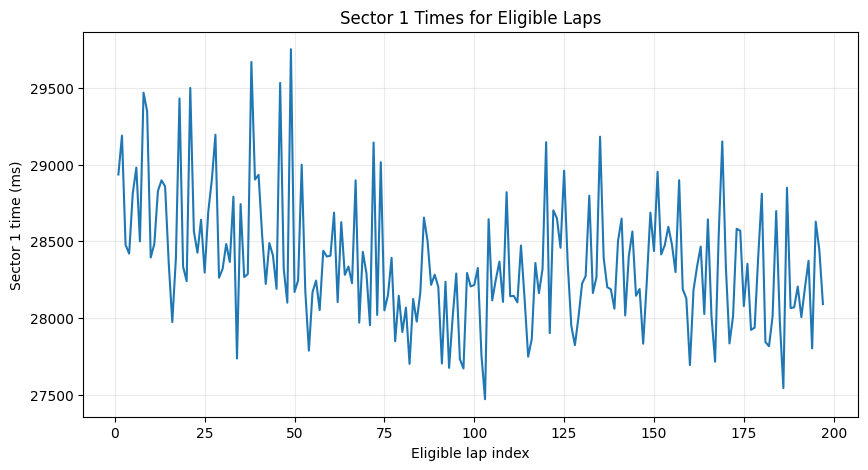

Eligible laps: 197


In [4]:
eligible_df = incident_free_df.loc[
    incident_free_df["s1_time"].lt(30_000)
].copy()

eligible_df["related_b_hits"] = eligible_df["related_b_hits"].apply(ast.literal_eval)
eligible_df["related_t_hits"] = eligible_df["related_t_hits"].apply(ast.literal_eval)

eligible_df = eligible_df.loc[
    eligible_df["related_b_hits"].apply(len).eq(2)
    & eligible_df["related_t_hits"].apply(len).eq(2)
].copy()

eligible_df = eligible_df.reset_index(drop=True)

eligible_lap_index = np.arange(1, len(eligible_df) + 1)

plt.figure(figsize=(10, 5))
plt.plot(eligible_lap_index, eligible_df["s1_time"])
plt.title("Sector 1 Times for Eligible Laps")
plt.xlabel("Eligible lap index")
plt.ylabel("Sector 1 time (ms)")
plt.grid(alpha=0.25)
plt.show()

print(f"Eligible laps: {len(eligible_df)}")


The final eligibility rules retain 197 of the 255 recorded laps.

Sector times generally become lower later in the collection period, suggesting that driving performance improved as more laps were completed. This trend is relevant when interpreting the data because the labels represent relative performance across the complete recorded dataset rather than performance from a driver whose skill remained perfectly constant.

Brake–throttle delta data was introduced after the first five sessions. Missing delta values from those sessions should therefore be treated as unavailable rather than as zero-second intervals.


In [5]:
def extract_delta_pair(value):
    # Return the first two recorded brake–throttle deltas, or NaN when unavailable.
    parsed = ast.literal_eval(value)

    if len(parsed) < 2:
        return pd.Series([np.nan, np.nan])

    return pd.Series([
        float(parsed[0][0]),
        float(parsed[1][0]),
    ])

eligible_df[["delta_1_seconds", "delta_2_seconds"]] = (
    eligible_df["brake_throttle_deltas"].apply(extract_delta_pair)
)

print(
    "Eligible laps with two recorded deltas:",
    eligible_df[["delta_1_seconds", "delta_2_seconds"]].notna().all(axis=1).sum()
)


Eligible laps with two recorded deltas: 169


## 3. Brake–Throttle Delta Exploration

The following plots use only laps for which both brake–throttle deltas are available. The two measurements are described as the first and second recorded deltas rather than being assigned permanently to specific corners.


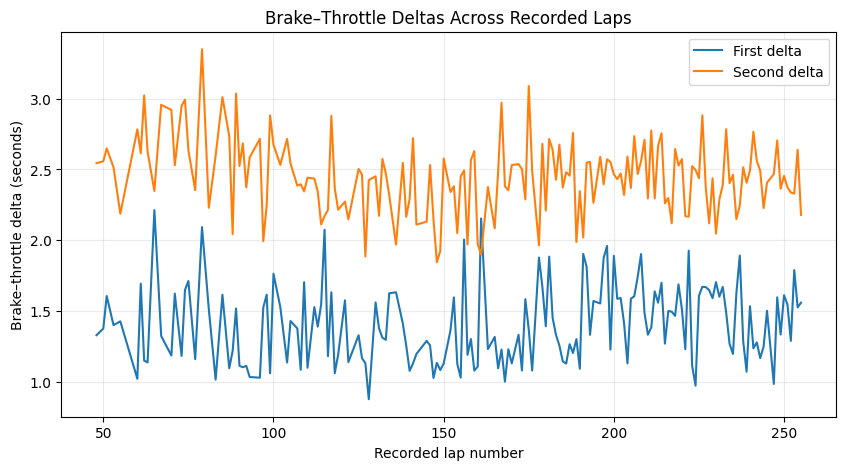

In [6]:
delta_df = eligible_df.dropna(
    subset=["delta_1_seconds", "delta_2_seconds"]
).copy()

plt.figure(figsize=(10, 5))
plt.plot(delta_df["lap_num"], delta_df["delta_1_seconds"], label="First delta")
plt.plot(delta_df["lap_num"], delta_df["delta_2_seconds"], label="Second delta")
plt.legend()
plt.title("Brake–Throttle Deltas Across Recorded Laps")
plt.xlabel("Recorded lap number")
plt.ylabel("Brake–throttle delta (seconds)")
plt.grid(alpha=0.25)
plt.show()


The brake–throttle deltas appear more stable over time than the Sector 1 times. This suggests that improvements in sector performance cannot be explained solely by large changes in these two timing measurements.

Other unrecorded factors—including steering input, racing line, corner-entry speed and the precise spatial position of each input—may also contribute to the improvement. The plot is exploratory and does not establish a causal relationship.


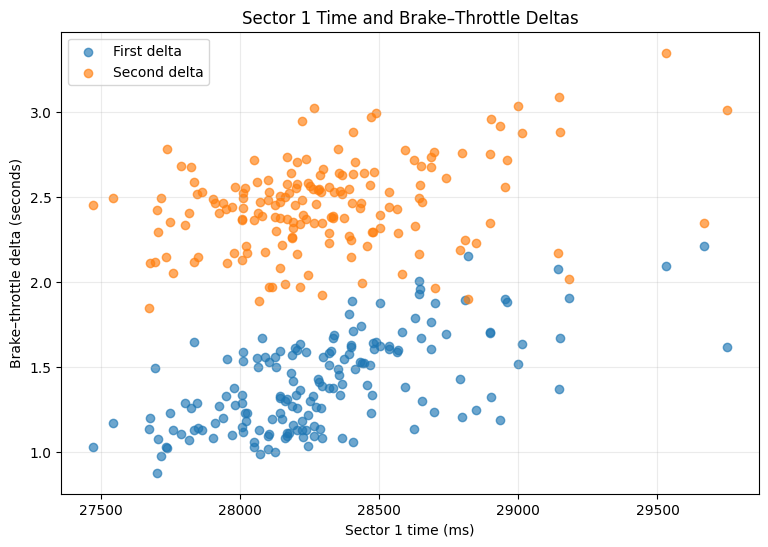

delta_1_seconds    0.631833
delta_2_seconds    0.324482
Name: Pearson correlation with Sector 1 time, dtype: float64

In [7]:
plt.figure(figsize=(9, 6))
plt.scatter(
    delta_df["s1_time"],
    delta_df["delta_1_seconds"],
    alpha=0.65,
    label="First delta"
)
plt.scatter(
    delta_df["s1_time"],
    delta_df["delta_2_seconds"],
    alpha=0.65,
    label="Second delta"
)
plt.legend()
plt.title("Sector 1 Time and Brake–Throttle Deltas")
plt.xlabel("Sector 1 time (ms)")
plt.ylabel("Brake–throttle delta (seconds)")
plt.grid(alpha=0.25)
plt.show()

delta_correlations = delta_df[
    ["s1_time", "delta_1_seconds", "delta_2_seconds"]
].corr().loc["s1_time", ["delta_1_seconds", "delta_2_seconds"]]

delta_correlations.rename("Pearson correlation with Sector 1 time")


## 4. Performance-Class Definition

The final models classify eligible laps into three performance groups:

- **Optimal**
- **Standard**
- **Sub-standard**

Crash and track-limits laps are excluded rather than treated as additional model classes. Their sector times and image sequences are not directly comparable with otherwise valid laps, and the number of incident examples is insufficient for reliable incident classification.

The class boundaries are based on the first and third quartiles of the Sector 1 times from the 197 eligible laps:

1. `Sector 1 time <= Q1` → **Optimal**
2. `Q1 < Sector 1 time < Q3` → **Standard**
3. `Sector 1 time >= Q3` → **Sub-standard**

This approach assigns approximately the fastest quarter of eligible laps to the optimal class, the middle half to the standard class and the slowest quarter to the sub-standard class. It avoids selecting arbitrary time thresholds and produces two similarly sized extreme-performance classes.


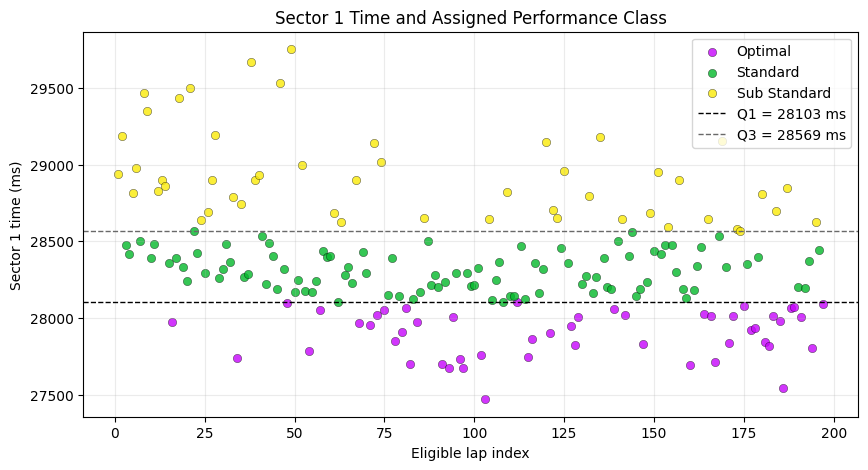

In [8]:
class_colours = {
    "optimal": "#c603fc",       # Purple
    "standard": "#04b82b",      # Green
    "sub_standard": "#faea07",  # Yellow
}

q1 = eligible_df["s1_time"].quantile(0.25)
q3 = eligible_df["s1_time"].quantile(0.75)

eligible_df["performance_class"] = np.select(
    [
        eligible_df["s1_time"].le(q1),
        eligible_df["s1_time"].lt(q3),
    ],
    [
        "optimal",
        "standard",
    ],
    default="sub_standard",
)

class_order = ["optimal", "standard", "sub_standard"]
class_counts = (
    eligible_df["performance_class"]
    .value_counts()
    .reindex(class_order)
)

plt.figure(figsize=(10, 5))

for class_name in class_order:
    mask = eligible_df["performance_class"].eq(class_name)

    plt.scatter(
        eligible_lap_index[mask],
        eligible_df.loc[mask, "s1_time"],
        color=class_colours[class_name],
        label=class_name.replace("_", " ").title(),
        alpha=0.8,
        edgecolors="black",
        linewidths=0.3,
    )

plt.axhline(
    q1,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Q1 = {q1:.0f} ms",
)

plt.axhline(
    q3,
    color="dimgray",
    linestyle="--",
    linewidth=1,
    label=f"Q3 = {q3:.0f} ms",
)

plt.legend()
plt.title("Sector 1 Time and Assigned Performance Class")
plt.xlabel("Eligible lap index")
plt.ylabel("Sector 1 time (ms)")
plt.grid(alpha=0.25)
plt.show()

## 5. Quantile Thresholds and Final Class Distribution

The quartiles are calculated after all eligibility filters have been applied. Therefore, the thresholds describe the distribution of the 197 laps that are actually available for class assignment and modelling.


In [9]:
threshold_summary = pd.DataFrame(
    {
        "Class": ["Optimal", "Standard", "Sub-standard"],
        "Sector 1 time rule": [
            f"<= {q1:.0f} ms",
            f"> {q1:.0f} ms and < {q3:.0f} ms",
            f">= {q3:.0f} ms",
        ],
        "Equivalent time in seconds": [
            f"<= {q1 / 1000:.3f} s",
            f"> {q1 / 1000:.3f} s and < {q3 / 1000:.3f} s",
            f">= {q3 / 1000:.3f} s",
        ],
        "Number of laps": class_counts.values,
    }
)

print(f"First quartile (Q1): {q1:.0f} ms ({q1 / 1000:.3f} s)")
print(f"Third quartile (Q3): {q3:.0f} ms ({q3 / 1000:.3f} s)")

threshold_summary


First quartile (Q1): 28103 ms (28.103 s)
Third quartile (Q3): 28569 ms (28.569 s)


,Class,Sector 1 time rule,Equivalent time in seconds,Number of laps
0,Optimal,<= 28103 ms,<= 28.103 s,50
1,Standard,> 28103 ms and < 28569 ms,> 28.103 s and < 28.569 s,97
2,Sub-standard,>= 28569 ms,>= 28.569 s,50


### Interpretation

For the final eligible dataset:

- **Q1 = 28,103 ms (28.103 s)**
- **Q3 = 28,569 ms (28.569 s)**
- **50 laps** are labelled optimal.
- **97 laps** are labelled standard.
- **50 laps** are labelled sub-standard.

The standard class is larger by design because it represents the middle half of the eligible performance distribution, while the optimal and sub-standard classes represent the faster and slower tails.

These labels are **relative to this recorded dataset**. An “optimal” lap means that the lap falls within the fastest quarter of the eligible observations collected for this project; it does not claim that the lap is objectively optimal in an absolute motorsport sense.

The labels are derived from Sector 1 time, while the models use screenshots and brake–throttle deltas as predictors. Consequently, the class definitions describe the outcome to be predicted but do not imply that the recorded inputs are the only causes of sector performance.

The quartile thresholds were fixed before the final model comparisons and were then used consistently throughout the train, validation, test and leave-one-session-out analyses.
